# mHealth Dataset 기반 LSTM 분류

## 결과 분석

LSTM2 Test accuracy: 95.03%

LSTM3 Test accuracy: 95.40%

LSTM layer 2개 모델은 95.03%, LSTM layer 3개 모델은 95.40%의 Test accuracy를 보였다.

Layer를 3개로 증가시켰을 때 성능이 약 향상된 것으로 보아 더 깊은 LSTM 구조가 mHealth 센서 데이터의 시간적 움직임 패턴을 조금 더 잘 학습한 것으로 판단된다.

하지만 Knees bending과 Waist bends forward처럼 유사한 굽힘 동작에서는 혼동이 발생하여 유사한 동작을 구분하기 위해 CNN 구조를 함께 사용하는 것이 성능 향상에 도움이 될 것이라고 판단된다.


In [206]:
# 라이브러리 import
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [207]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [208]:
import os
import pandas as pd

# mHealth raw 데이터 로드
base_dir = "/content/drive/MyDrive"

FEATURE_COLUMNS = [f'sensor_{i+1}' for i in range(23)]
LABEL_COLUMN = 'label'
SUBJECT_COLUMN = 'subject'

LABELS = [
    'Standing still',
    'Sitting and relaxing',
    'Lying down',
    'Walking',
    'Climbing stairs',
    'Waist bends forward',
    'Frontal elevation of arms',
    'Knees bending',
    'Cycling',
    'Jogging',
    'Running',
    'Jump front and back'
]

dfs = []

for i in range(1, 11):
    path = os.path.join(base_dir, f"mHealth_subject{i}.log")

    df_i = pd.read_csv(path, sep=r"\s+", header=None)
    df_i.columns = FEATURE_COLUMNS + [LABEL_COLUMN]
    df_i[SUBJECT_COLUMN] = i

    dfs.append(df_i)

data = pd.concat(dfs, ignore_index=True)

print(data.shape)
print(data.head())

(1215745, 25)
   sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  sensor_6  sensor_7  \
0   -9.8184  0.009971   0.29563  0.004186  0.004186    2.1849   -9.6967   
1   -9.8489  0.524040   0.37348  0.004186  0.016745    2.3876   -9.5080   
2   -9.6602  0.181850   0.43742  0.016745  0.037677    2.4086   -9.5674   
3   -9.6507  0.214220   0.24033  0.079540  0.117220    2.1814   -9.4301   
4   -9.7030  0.303890   0.31156  0.221870  0.205130    2.4173   -9.3889   

   sensor_8  sensor_9  sensor_10  ...  sensor_16  sensor_17  sensor_18  \
0   0.63077  0.103900   -0.84053  ...    -4.5781   0.187760   -0.44902   
1   0.68389  0.085343   -0.83865  ...    -4.3198   0.023595   -0.44902   
2   0.68113  0.085343   -0.83865  ...    -4.2772   0.275720   -0.44902   
3   0.55031  0.085343   -0.83865  ...    -4.3163   0.367520   -0.45686   
4   0.71098  0.085343   -0.83865  ...    -4.1459   0.407290   -0.45686   

   sensor_19  sensor_20  sensor_21  sensor_22  sensor_23  label  subject  
0    -1.0103   

## 데이터 전처리

1. **mHealth 로그 파일 로드**
2. **클린업**: 라벨 0 제거, 23개 센서 컬럼을 float32로 변환
3. **Label Encoding**: mHealth activity 이름을 정수 라벨로 변환
4. **Data Split (subject 기반)**:
  - subject 1~7: train
  - subject 8: validation
  - subject 9~10: test
5. **정규화**: StandardScaler를 train에서 fit, val/test는 transform만
6. **Segmentation**: sliding window (TIME_STEPS=200, STEP=40)


In [209]:
# 클린업
# 라벨 0은 비활동/전환 구간이므로 실제 12개 activity만 사용
df = data[data[LABEL_COLUMN] > 0].copy()

# 센서 값을 float32 숫자형으로 변환
for col in FEATURE_COLUMNS:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype(np.float32)

df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(np.int32)
df[SUBJECT_COLUMN] = df[SUBJECT_COLUMN].astype(np.int32)
df = df.dropna().reset_index(drop=True)

# 라벨 번호를 activity 이름으로 변환
df['activity'] = df[LABEL_COLUMN].map(lambda label: LABELS[label - 1])

In [210]:
# Label Encoding
label_encoder = LabelEncoder()
df['activity_encoded'] = label_encoder.fit_transform(df['activity'])
num_classes = len(label_encoder.classes_)
print()
print('Label mapping:', dict(enumerate(label_encoder.classes_)))


Label mapping: {0: 'Climbing stairs', 1: 'Cycling', 2: 'Frontal elevation of arms', 3: 'Jogging', 4: 'Jump front and back', 5: 'Knees bending', 6: 'Lying down', 7: 'Running', 8: 'Sitting and relaxing', 9: 'Standing still', 10: 'Waist bends forward', 11: 'Walking'}


In [211]:
# Data Split (subject 기반)
# subject 1~7 = train set
# subject 8 = validation set
# subject 9~10 = test set
TRAIN_SUBJECTS = list(range(1, 8))
VAL_SUBJECTS = [8]
TEST_SUBJECTS = [9, 10]

df_train = df[df[SUBJECT_COLUMN].isin(TRAIN_SUBJECTS)].copy()
df_val   = df[df[SUBJECT_COLUMN].isin(VAL_SUBJECTS)].copy()
df_test  = df[df[SUBJECT_COLUMN].isin(TEST_SUBJECTS)].copy()

In [212]:
# 정규화
scaler = StandardScaler()

df_train.loc[:, FEATURE_COLUMNS] = scaler.fit_transform(df_train.loc[:, FEATURE_COLUMNS])

if not df_val.empty:
    df_val.loc[:, FEATURE_COLUMNS] = scaler.transform(df_val.loc[:, FEATURE_COLUMNS])

if not df_test.empty:
    df_test.loc[:, FEATURE_COLUMNS] = scaler.transform(df_test.loc[:, FEATURE_COLUMNS])

In [213]:
# Segmentation (Sliding Window)
# 연속된 센서 데이터를 고정 길이 window로 분할
# subject와 activity segment 경계를 넘는 window가 생기지 않도록 그룹별로 생성
def create_dataset(df_split, time_steps=200, step=40):
    xs, ys = [], []

    if df_split.empty:
        return np.empty((0, time_steps, len(FEATURE_COLUMNS)), dtype=np.float32), np.empty((0,), dtype=np.int32)

    df_split = df_split.copy()
    segment_id = df_split.groupby(SUBJECT_COLUMN)['activity_encoded'].transform(lambda s: s.ne(s.shift()).cumsum())
    df_split['segment'] = segment_id

    for _, segment in df_split.groupby([SUBJECT_COLUMN, 'segment'], sort=False):
        x_values = segment[FEATURE_COLUMNS].to_numpy(dtype=np.float32)
        y_value = int(segment['activity_encoded'].iloc[0])

        for i in range(0, len(x_values) - time_steps + 1, step):
            xs.append(x_values[i:i + time_steps])
            ys.append(y_value)

    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.int32)


TIME_STEPS = 200
STEP = 40
x_train, y_train = create_dataset(df_train, TIME_STEPS, STEP)
x_val,   y_val   = create_dataset(df_val,   TIME_STEPS, STEP)
x_test,  y_test  = create_dataset(df_test,  TIME_STEPS, STEP)

print()
print(f'x_train: {x_train.shape}, y_train: {y_train.shape}')
print(f'x_val  : {x_val.shape},  y_val  : {y_val.shape}')
print(f'x_test : {x_test.shape},  y_test : {y_test.shape}')
print('train label distribution:', np.bincount(y_train, minlength=num_classes))
print('val label distribution:', np.bincount(y_val, minlength=num_classes))
print('test label distribution:', np.bincount(y_test, minlength=num_classes))


x_train: (5650, 200, 23), y_train: (5650,)
x_val  : (777, 200, 23),  y_val  : (777,)
x_test : (1588, 200, 23),  y_test : (1588,)
train label distribution: [504 504 488 504 148 492 504 504 504 504 490 504]
val label distribution: [72 72 71 72 21 60 72 72 72 72 49 72]
test label distribution: [144 144 132 144  43 137 144 144 144 144 124 144]


In [214]:
# 클래스 가중치 (불균형 보정)
# 모델이 적은 class도 무시하지 않도록
classes = np.unique(y_train)
weights = class_weight.compute_class_weight('balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))
print('Class weights:', class_weights_dict)

Class weights: {np.int32(0): np.float64(0.9341931216931217), np.int32(1): np.float64(0.9341931216931217), np.int32(2): np.float64(0.9648224043715847), np.int32(3): np.float64(0.9341931216931217), np.int32(4): np.float64(3.1813063063063063), np.int32(5): np.float64(0.9569783197831978), np.int32(6): np.float64(0.9341931216931217), np.int32(7): np.float64(0.9341931216931217), np.int32(8): np.float64(0.9341931216931217), np.int32(9): np.float64(0.9341931216931217), np.int32(10): np.float64(0.9608843537414966), np.int32(11): np.float64(0.9341931216931217)}


## Model 1
- LSTM 2층

In [215]:
# LSTM input shape: (timesteps, features)
input_shape = (x_train.shape[1], x_train.shape[2])

# Number of activity classes
num_classes = len(label_encoder.classes_)

# Model definition
model1 = Sequential([
            Input(shape=input_shape), # time_steps, n_features
            LSTM(128, return_sequences=True, dropout=0.2),
            LSTM(64, dropout=0.2),
            Dense(32, activation='relu'),
            Dropout(0.3),
            Dense(num_classes, activation='softmax')
        ])

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

print(model1.summary())

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_49 (LSTM)                  │ (None, 200, 128)       │        77,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_50 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 12)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,708 (506.67 KB)

 Trainable params: 129,708 (506.67 KB)

 Non-trainable params: 0 (0.00 B)

None


In [216]:
callbacks1 = [
    ModelCheckpoint(
        "mHealth_HAR_LSTM2_best.h5",
        save_best_only=True,
        monitor="val_sparse_categorical_accuracy",
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor="val_sparse_categorical_accuracy",
        patience=20,
        verbose=1,
        mode='max',
        restore_best_weights=True
    )
]

history1 = model1.fit(
    x_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(x_val, y_val),
    callbacks=callbacks1,
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/100
176/177 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.7797 - sparse_categorical_accuracy: 0.4222
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.57400, saving model to mHealth_HAR_LSTM2_best.h5



Epoch 1: finished saving model to mHealth_HAR_LSTM2_best.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 1.2722 - sparse_categorical_accuracy: 0.6147 - val_loss: 1.4095 - val_sparse_categorical_accuracy: 0.5740
Epoch 2/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.6824 - sparse_categorical_accuracy: 0.8017
Epoch 2: val_sparse_categorical_accuracy improved from 0.57400 to 0.90090, saving model to mHealth_HAR_LSTM2_best.h5



Epoch 2: finished saving model to mHealth_HAR_LSTM2_best.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.5668 - sparse_categorical_accuracy: 0.8407 - val_loss: 0.3223 - val_sparse_categorical_accuracy: 0.9009
Epoch 3/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4971 - sparse_categorical_accuracy: 0.8507
Epoch 3: val_sparse_categorical_accuracy did not improve from 0.90090
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.4692 - sparse_categorical_accuracy: 0.8632 - val_loss: 0.5631 - val_sparse_categorical_accuracy: 0.8288
Epoch 4/100
174/177 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3892 - sparse_categorical_accuracy: 0.8933
Epoch 4: val_sparse_categorical_accuracy did not improve from 0.90090
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.4228 - sparse_categorical_accuracy: 0.8865 - val_loss: 0.4849 - val_sparse_categorical_accuracy: 0.8340
Epoch 5/100
175/177 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.4177 - sparse_categorical_accuracy: 0.8840
Epoch 5: v


Epoch 13: finished saving model to mHealth_HAR_LSTM2_best.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.3418 - sparse_categorical_accuracy: 0.8982 - val_loss: 0.1364 - val_sparse_categorical_accuracy: 0.9807
Epoch 14/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2860 - sparse_categorical_accuracy: 0.9192
Epoch 14: val_sparse_categorical_accuracy improved from 0.98070 to 0.99871, saving model to mHealth_HAR_LSTM2_best.h5



Epoch 14: finished saving model to mHealth_HAR_LSTM2_best.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.2375 - sparse_categorical_accuracy: 0.9354 - val_loss: 0.0274 - val_sparse_categorical_accuracy: 0.9987
Epoch 15/100
176/177 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1941 - sparse_categorical_accuracy: 0.9493
Epoch 15: val_sparse_categorical_accuracy improved from 0.99871 to 1.00000, saving model to mHealth_HAR_LSTM2_best.h5



Epoch 15: finished saving model to mHealth_HAR_LSTM2_best.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.1928 - sparse_categorical_accuracy: 0.9481 - val_loss: 0.0297 - val_sparse_categorical_accuracy: 1.0000
Epoch 16/100
176/177 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1435 - sparse_categorical_accuracy: 0.9607
Epoch 16: val_sparse_categorical_accuracy did not improve from 1.00000
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.1388 - sparse_categorical_accuracy: 0.9612 - val_loss: 0.0261 - val_sparse_categorical_accuracy: 0.9974
Epoch 17/100
174/177 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1334 - sparse_categorical_accuracy: 0.9698
Epoch 17: val_sparse_categorical_accuracy did not improve from 1.00000
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.1235 - sparse_categorical_accuracy: 0.9715 - val_loss: 0.2401 - val_sparse_categorical_accuracy: 0.9266
Epoch 18/100
174/177 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0943 - sparse_categorical_accuracy: 0.9786
Epoc

In [217]:
# Model 1 evaluation
model1 = tf.keras.models.load_model("mHealth_HAR_LSTM2_best.h5")

train_loss, train_acc = model1.evaluate(x_train, y_train, verbose=0)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

test_loss, test_acc = model1.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 99.75%
Training loss: 0.0180
Test accuracy: 95.03%
Test loss: 0.2044


In [218]:
y_pred_proba = model1.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))


Classification Report:
                           precision    recall  f1-score   support

          Climbing stairs     1.0000    0.9236    0.9603       144
                  Cycling     1.0000    1.0000    1.0000       144
Frontal elevation of arms     1.0000    0.9924    0.9962       132
                  Jogging     1.0000    1.0000    1.0000       144
      Jump front and back     1.0000    1.0000    1.0000        43
            Knees bending     0.8861    0.5109    0.6481       137
               Lying down     1.0000    1.0000    1.0000       144
                  Running     1.0000    1.0000    1.0000       144
     Sitting and relaxing     0.9931    1.0000    0.9965       144
           Standing still     0.9931    1.0000    0.9965       144
      Waist bends forward     0.6458    1.0000    0.7848       124
                  Walking     1.0000    1.0000    1.0000       144

                 accuracy                         0.9503      1588
                macro avg     0.9598

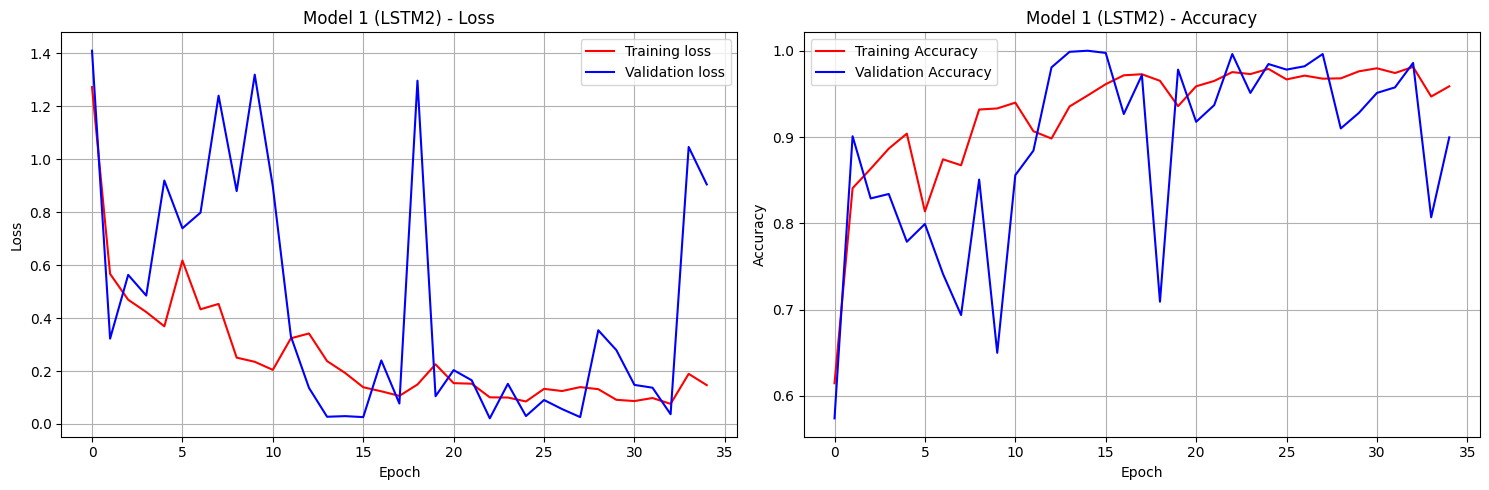

In [219]:
train_loss = history1.history['loss']
train_accuracy = history1.history['sparse_categorical_accuracy']
val_loss = history1.history['val_loss']
val_accuracy = history1.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss')
plt.plot(val_loss, 'b', label='Validation loss')
plt.title('Model 1 (LSTM2) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.plot(val_accuracy, 'b', label='Validation Accuracy')
plt.title('Model 1 (LSTM2) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

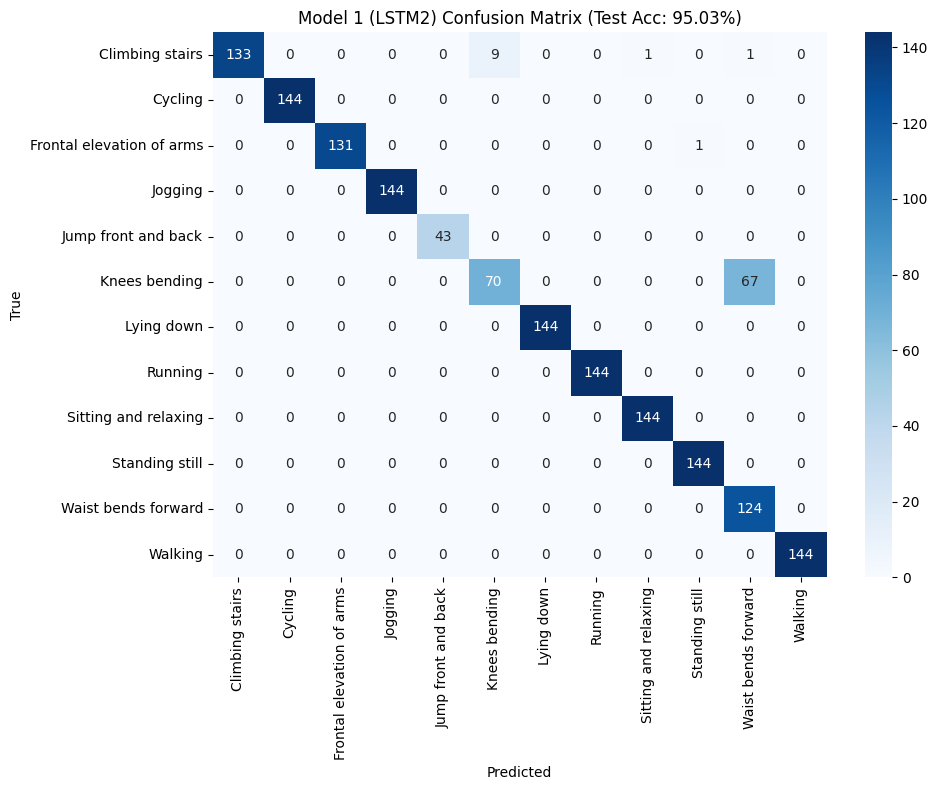

In [220]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Model 1 (LSTM2) Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## Model 2
- LSTM 3층

In [221]:
model2 = Sequential([
            Input(shape=input_shape), # time_steps, n_features
            LSTM(128, return_sequences=True, dropout=0.2),
            LSTM(128, return_sequences=True, dropout=0.2),
            LSTM(64, dropout=0.2),
            Dense(32, activation='relu'),
            Dropout(0.3),
            Dense(num_classes, activation='softmax')
        ])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

print(model2.summary())

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_51 (LSTM)                  │ (None, 200, 128)       │        77,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_52 (LSTM)                  │ (None, 200, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_53 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 12)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,292 (1020.67 KB)

 Trainable params: 261,292 (1020.67 KB)

 Non-trainable params: 0 (0.00 B)

None


In [222]:
callbacks2 = [
    ModelCheckpoint(
        "mHealth_HAR_LSTM3_best.h5",
        save_best_only=True,
        monitor="val_sparse_categorical_accuracy",
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_sparse_categorical_accuracy",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_sparse_categorical_accuracy",
        patience=20,
        verbose=1,
        mode='max',
        restore_best_weights=True
    )
]

history2 = model2.fit(
    x_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(x_val, y_val),
    callbacks=callbacks2,
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/100
176/177 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.7222 - sparse_categorical_accuracy: 0.4464
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.59202, saving model to mHealth_HAR_LSTM3_best.h5



Epoch 1: finished saving model to mHealth_HAR_LSTM3_best.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - loss: 1.2117 - sparse_categorical_accuracy: 0.6170 - val_loss: 1.3339 - val_sparse_categorical_accuracy: 0.5920 - learning_rate: 0.0010
Epoch 2/100
175/177 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.6633 - sparse_categorical_accuracy: 0.8103
Epoch 2: val_sparse_categorical_accuracy improved from 0.59202 to 0.64350, saving model to mHealth_HAR_LSTM3_best.h5



Epoch 2: finished saving model to mHealth_HAR_LSTM3_best.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - loss: 0.6581 - sparse_categorical_accuracy: 0.8119 - val_loss: 1.1135 - val_sparse_categorical_accuracy: 0.6435 - learning_rate: 0.0010
Epoch 3/100
175/177 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.4952 - sparse_categorical_accuracy: 0.8613
Epoch 3: val_sparse_categorical_accuracy improved from 0.64350 to 0.76062, saving model to mHealth_HAR_LSTM3_best.h5



Epoch 3: finished saving model to mHealth_HAR_LSTM3_best.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.4842 - sparse_categorical_accuracy: 0.8607 - val_loss: 1.1138 - val_sparse_categorical_accuracy: 0.7606 - learning_rate: 0.0010
Epoch 4/100
176/177 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.7103 - sparse_categorical_accuracy: 0.7902
Epoch 4: val_sparse_categorical_accuracy improved from 0.76062 to 0.81725, saving model to mHealth_HAR_LSTM3_best.h5



Epoch 4: finished saving model to mHealth_HAR_LSTM3_best.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.6157 - sparse_categorical_accuracy: 0.8122 - val_loss: 0.6349 - val_sparse_categorical_accuracy: 0.8172 - learning_rate: 0.0010
Epoch 5/100
175/177 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.4280 - sparse_categorical_accuracy: 0.8859
Epoch 5: val_sparse_categorical_accuracy improved from 0.81725 to 0.84041, saving model to mHealth_HAR_LSTM3_best.h5



Epoch 5: finished saving model to mHealth_HAR_LSTM3_best.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.3993 - sparse_categorical_accuracy: 0.8935 - val_loss: 0.4562 - val_sparse_categorical_accuracy: 0.8404 - learning_rate: 0.0010
Epoch 6/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.2916 - sparse_categorical_accuracy: 0.9231
Epoch 6: val_sparse_categorical_accuracy improved from 0.84041 to 0.87387, saving model to mHealth_HAR_LSTM3_best.h5



Epoch 6: finished saving model to mHealth_HAR_LSTM3_best.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.2856 - sparse_categorical_accuracy: 0.9271 - val_loss: 0.5974 - val_sparse_categorical_accuracy: 0.8739 - learning_rate: 0.0010
Epoch 7/100
175/177 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.2439 - sparse_categorical_accuracy: 0.9338
Epoch 7: val_sparse_categorical_accuracy did not improve from 0.87387
177/177 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 0.2752 - sparse_categorical_accuracy: 0.9244 - val_loss: 0.9381 - val_sparse_categorical_accuracy: 0.8172 - learning_rate: 0.0010
Epoch 8/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.2385 - sparse_categorical_accuracy: 0.9412
Epoch 8: val_sparse_categorical_accuracy did not improve from 0.87387
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.2406 - sparse_categorical_accuracy: 0.9365 - val_loss: 0.7097 - val_sparse_categorical_accuracy: 0.7799 - learning_rate: 0.0010
Epoch 9/100
176/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2


Epoch 9: finished saving model to mHealth_HAR_LSTM3_best.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.2011 - sparse_categorical_accuracy: 0.9510 - val_loss: 0.2816 - val_sparse_categorical_accuracy: 0.9189 - learning_rate: 0.0010
Epoch 10/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.2254 - sparse_categorical_accuracy: 0.9340
Epoch 10: val_sparse_categorical_accuracy did not improve from 0.91892
177/177 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 0.2325 - sparse_categorical_accuracy: 0.9370 - val_loss: 0.8389 - val_sparse_categorical_accuracy: 0.7516 - learning_rate: 0.0010
Epoch 11/100
176/177 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.2561 - sparse_categorical_accuracy: 0.9209
Epoch 11: val_sparse_categorical_accuracy did not improve from 0.91892
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.2524 - sparse_categorical_accuracy: 0.9067 - val_loss: 0.6677 - val_sparse_categorical_accuracy: 0.8314 - learning_rate: 0.0010
Epoch 12/100
177/177 ━━━━━━━━━━━━━━━━━━━━


Epoch 13: finished saving model to mHealth_HAR_LSTM3_best.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.4415 - sparse_categorical_accuracy: 0.8639 - val_loss: 0.1935 - val_sparse_categorical_accuracy: 0.9395 - learning_rate: 0.0010
Epoch 14/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.2889 - sparse_categorical_accuracy: 0.9160
Epoch 14: val_sparse_categorical_accuracy improved from 0.93951 to 0.98842, saving model to mHealth_HAR_LSTM3_best.h5



Epoch 14: finished saving model to mHealth_HAR_LSTM3_best.h5
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.2853 - sparse_categorical_accuracy: 0.9179 - val_loss: 0.0812 - val_sparse_categorical_accuracy: 0.9884 - learning_rate: 0.0010
Epoch 15/100
176/177 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1908 - sparse_categorical_accuracy: 0.9539
Epoch 15: val_sparse_categorical_accuracy did not improve from 0.98842
177/177 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.2020 - sparse_categorical_accuracy: 0.9485 - val_loss: 0.2060 - val_sparse_categorical_accuracy: 0.8970 - learning_rate: 0.0010
Epoch 16/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1936 - sparse_categorical_accuracy: 0.9554
Epoch 16: val_sparse_categorical_accuracy did not improve from 0.98842
177/177 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.2040 - sparse_categorical_accuracy: 0.9535 - val_loss: 0.8778 - val_sparse_categorical_accuracy: 0.8893 - learning_rate: 0.0010
Epoch 17/100
177/177 ━━━━━━━━━━━━━━━━━━━

In [223]:
# Model 2 evaluation
model2 = tf.keras.models.load_model("mHealth_HAR_LSTM3_best.h5")

train_loss, train_acc = model2.evaluate(x_train, y_train, verbose=0)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

test_loss, test_acc = model2.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 99.68%
Training loss: 0.0400
Test accuracy: 95.40%
Test loss: 0.2093


In [224]:
y_pred_proba = model2.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))


Classification Report:
                           precision    recall  f1-score   support

          Climbing stairs     1.0000    0.8750    0.9333       144
                  Cycling     0.9412    1.0000    0.9697       144
Frontal elevation of arms     1.0000    1.0000    1.0000       132
                  Jogging     1.0000    1.0000    1.0000       144
      Jump front and back     1.0000    1.0000    1.0000        43
            Knees bending     0.8454    0.5985    0.7009       137
               Lying down     1.0000    1.0000    1.0000       144
                  Running     1.0000    1.0000    1.0000       144
     Sitting and relaxing     0.9600    1.0000    0.9796       144
           Standing still     1.0000    1.0000    1.0000       144
      Waist bends forward     0.7425    1.0000    0.8522       124
                  Walking     1.0000    1.0000    1.0000       144

                 accuracy                         0.9540      1588
                macro avg     0.9574

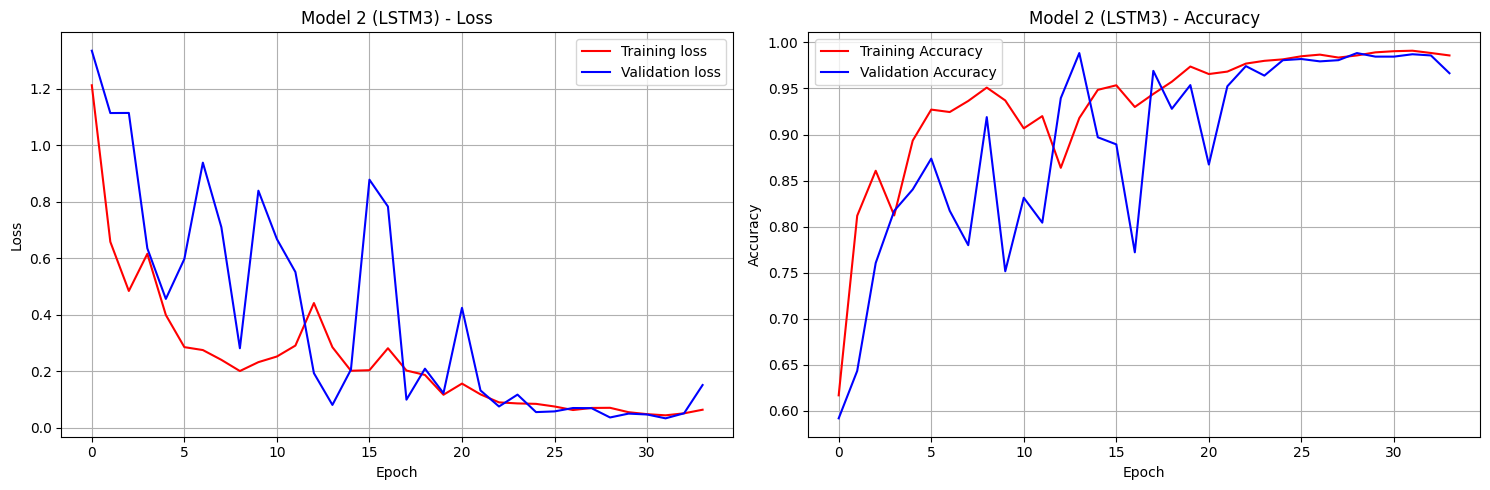

In [225]:
train_loss = history2.history['loss']
train_accuracy = history2.history['sparse_categorical_accuracy']
val_loss = history2.history['val_loss']
val_accuracy = history2.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss')
plt.plot(val_loss, 'b', label='Validation loss')
plt.title('Model 2 (LSTM3) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.plot(val_accuracy, 'b', label='Validation Accuracy')
plt.title('Model 2 (LSTM3) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

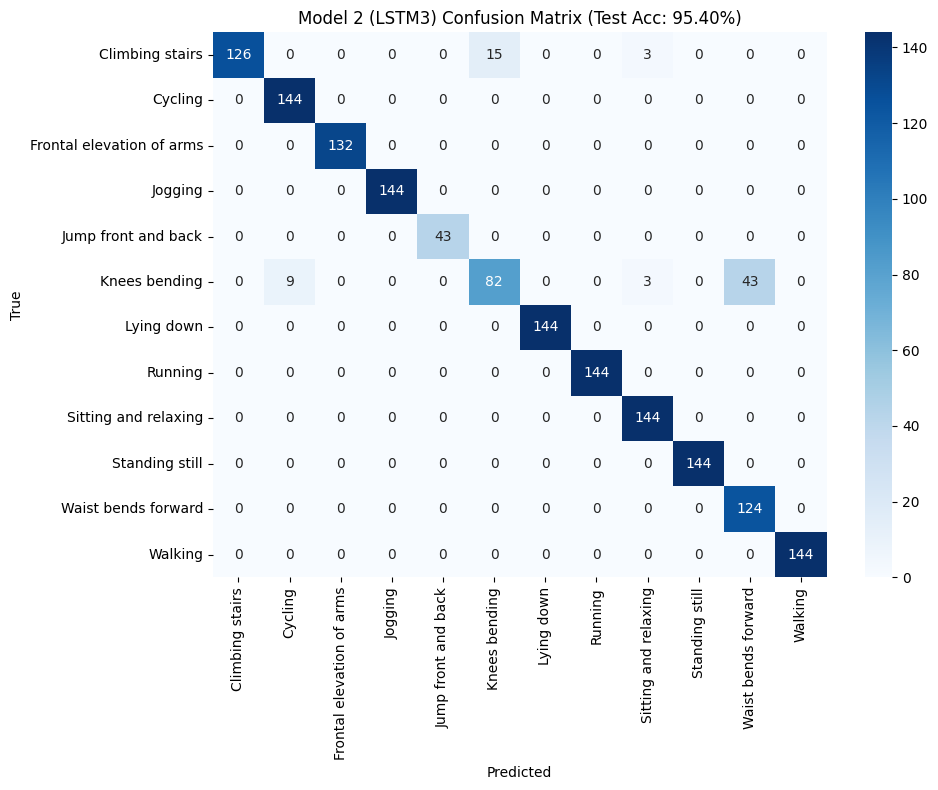

In [226]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Model 2 (LSTM3) Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()